In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import TensorDataset
from tqdm import tqdm

import dataset as ds

## Constants

In [55]:
#DATA_PATH  = "../Data/TestUniform"  # adjust as needed
DATA_PATH  = "/lustre/ific.uv.es/ml/uovi123/snncalo/PhotonData/PrimaryOnly"
PARTICLES  = ["proton", "kaon", "pion"]
MAX_FILES  = 50   # per particle; increase for the full dataset

# Mirror the constants in dataset.py
nSensors  = ds.nSensors   # 100
timesteps = ds.timesteps  # 100
max_t     = ds.max_t      # 20 ns
dt        = ds.dt         # 0.2 ns

In [56]:
labels_map = {
    0: "proton",
    1: "kaon",
    2: "pion",
    3: "other",
}
nClasses = len(labels_map)

## Dataset Creation

Load all `.dat` files with `primary_only=False` so every record includes the primary-cublet flag.
We then keep only the records where that flag equals 1, which is equivalent to calling
`dataset.clean(lambda x: x[1] == 1)` on a dataset loaded with `target="primary"`.

In [57]:
data = ds.build_dataset(DATA_PATH, MAX_FILES, lazy=True, primary_only=True, target=['energy'])
energy = np.array([d[1][0] for d in data])

Indexing /lustre/ific.uv.es/ml/uovi123/snncalo/PhotonData/PrimaryOnly/kaon/kaon_14.dat ...
Indexing /lustre/ific.uv.es/ml/uovi123/snncalo/PhotonData/PrimaryOnly/kaon/kaon_15.dat ...
Indexing /lustre/ific.uv.es/ml/uovi123/snncalo/PhotonData/PrimaryOnly/kaon/kaon_16.dat ...
Indexing /lustre/ific.uv.es/ml/uovi123/snncalo/PhotonData/PrimaryOnly/kaon/kaon_17.dat ...
Indexing /lustre/ific.uv.es/ml/uovi123/snncalo/PhotonData/PrimaryOnly/kaon/kaon_18.dat ...
Indexing /lustre/ific.uv.es/ml/uovi123/snncalo/PhotonData/PrimaryOnly/kaon/kaon_19.dat ...
Indexing /lustre/ific.uv.es/ml/uovi123/snncalo/PhotonData/PrimaryOnly/kaon/kaon_2.dat ...
Indexing /lustre/ific.uv.es/ml/uovi123/snncalo/PhotonData/PrimaryOnly/kaon/kaon_20.dat ...
Indexing /lustre/ific.uv.es/ml/uovi123/snncalo/PhotonData/PrimaryOnly/kaon/kaon_21.dat ...
Indexing /lustre/ific.uv.es/ml/uovi123/snncalo/PhotonData/PrimaryOnly/kaon/kaon_22.dat ...
Indexing /lustre/ific.uv.es/ml/uovi123/snncalo/PhotonData/PrimaryOnly/kaon/kaon_23.dat ...


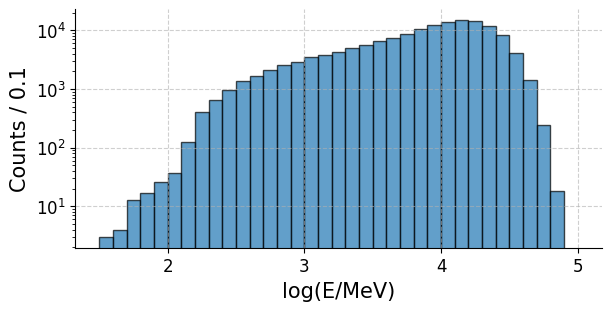

In [58]:
energy_log = np.log10(energy[energy > 0] )  # Convert to log(E/MeV)
dims=["log(E/MeV)"]
fig, axs = plt.subplots(ncols=len(dims), nrows=1, facecolor="w", figsize=(6*len(dims), 3),constrained_layout=True)     
n = 10
bins=np.arange(1.5, 5+1/n, 1/n)
axs.set_ylabel(f"Counts / {1/n}", fontsize=15)
for i in range(len(dims)):    
    axs.set_xlabel(dims[i], fontsize=15)
    axs.grid(True, linestyle='--', alpha=0.6)
    axs.spines['top'].set_visible(False)
    axs.spines['right'].set_visible(False)
    axs.set_yscale('log')
        
    axs.tick_params(axis='both', which='major', labelsize=12)
    axs.set_xticks([i for i in range(7)])
    hist = axs.hist(energy_log, bins, edgecolor='black', alpha=0.7)

In [59]:
data = ds.build_dataset(DATA_PATH, MAX_FILES, lazy=True, primary_only=True, target=['centroid', 'dispersion'])

centroid = np.array([d[1][0] for d in data])
dispersion = np.array([d[1][1] for d in data])

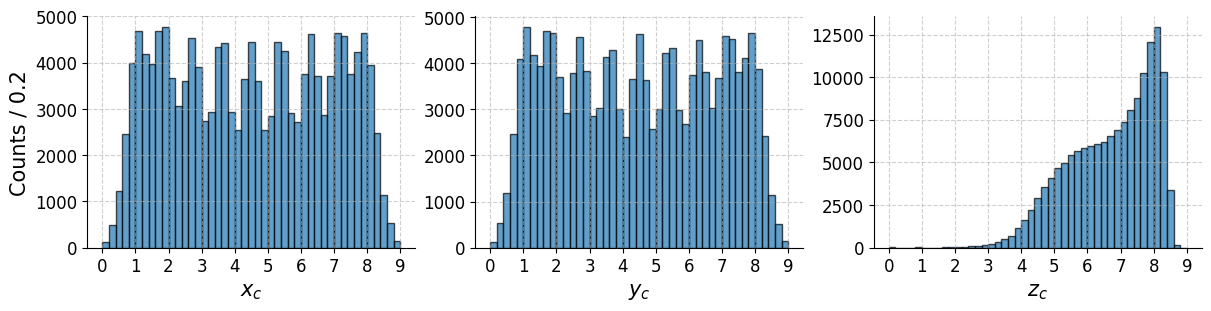

In [60]:
dims=[r"$x_c$", r"$y_c$", r"$z_c$"]
fig, axs = plt.subplots(ncols=len(dims), nrows=1, facecolor="w", figsize=(4*len(dims), 3),constrained_layout=True)     
n = 5
bins=np.arange(0, 9+1/n, 1/n)
axs[0].set_ylabel(f"Counts / {1/n}", fontsize=15)
for i in range(len(dims)):    
    positions = centroid[:, i]
    axs[i].set_xlabel(dims[i], fontsize=15)
    axs[i].grid(True, linestyle='--', alpha=0.6)
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    #axs[i].set_yscale('log')
        
    axs[i].tick_params(axis='both', which='major', labelsize=12)
    axs[i].set_xticks([i for i in range(10)])
    hist = axs[i].hist(positions, bins, edgecolor='black', alpha=0.7)

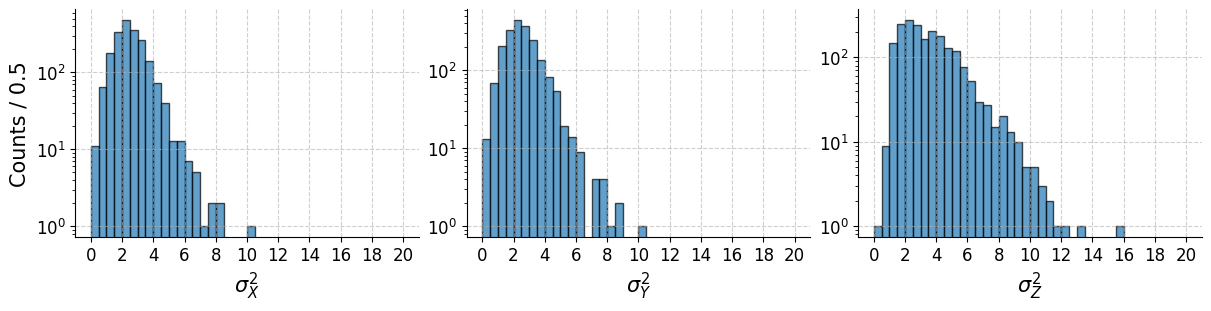

In [54]:
dims=["X", "Y", "Z"]
fig, axs = plt.subplots(ncols=len(dims), nrows=1, facecolor="w", figsize=(4*len(dims), 3),constrained_layout=True)     
n = 2
bins=np.arange(0, 20+1/n, 1/n)
axs[0].set_ylabel(f"Counts / {1/n}", fontsize=15)
for i in range(len(dims)):    
    dispersions = dispersion[:, i]
    axs[i].set_xlabel(dims[i], fontsize=15)
    axs[i].grid(True, linestyle='--', alpha=0.6)
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    axs[i].set_yscale('log')
        
    axs[i].tick_params(axis='both', which='major', labelsize=12)
    axs[i].set_xticks([2*i for i in range(11)])
    hist = axs[i].hist(dispersions, bins, edgecolor='black', alpha=0.7)
    axs[i].set_xlabel(rf"$\sigma^2_{dims[i]}$")